# Como criar uma rede Neural ?

In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt


In [2]:
class LineNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential( #o Sequential é usado para momentos em que temos mais de uma camada, neste caso, temos apenas uma camada
        nn.Linear(1,1) #diz que o neurônio pega um valor e devolve apenas um valor também
    )

    self.layers = nn.Linear(1,1)

  #diz o que a rede vai fazer com o dado que entra
  def forward(self, x):
    return  self.layers(x)




# Como treinar sua Rede Neural

## 3.1 Preparando a Infraestrutura de Dados

In [3]:
from torch.utils.data import Dataset, DataLoader
import torch.distributions.uniform as urand

In [4]:

class AlgebraicDataset(Dataset):
  def __init__(self, f, interval,nsamples): # f é a função do modelo, interval é o intervalo numérico dos pontos e nsamples é a quantidade de pontos que temos na amostra
    X = urand.Uniform(interval[0], interval[1]).sample([nsamples])
    self.data = [(x, f(x)) for x in X ]

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    return self.data[idx]

In [5]:
line = lambda x: 2*x + 3
interval = (-10,10)
train_nsamples = 1000
test_nsamples = 100

In [6]:
train_data = AlgebraicDataset(line, interval, train_nsamples)
test_data = AlgebraicDataset(line, interval, test_nsamples)

train_dataloader = DataLoader(train_data, batch_size = 32, shuffle=True) #batch_size diz a quantidade de dados que serão fornecidos,
                                      #pois em situações em que há uma grande quantidade de dados é muito ruim processá-los todos de uma só vez
                                      #Shuffle -> embaralha os dados
test_dataloader = DataLoader(test_data, batch_size = test_nsamples, shuffle=True)

## 3.2 Hiperparâmetros de Otimização

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Rodando em {device}')

Rodando em cuda


In [8]:
model = LineNetwork()

In [9]:
#Função de perda (Loss Func)
lossfunc = nn.MSELoss() #MSE - Mean Square Error
#SGD = Stochastic Gradient Descent
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3) #lr - learning rate

In [10]:
def train(model, dataloader, lossfunc, optimizer):
  model.train()

  cumloss = 0.0

  for X, y in dataloader:
    X = X.unsqueeze(1).float().to(device)
    y = y.unsqueeze(1).float().to(device)

    pred = model(X)
    loss = lossfunc(pred, y)
    # zera os gradientes acumulados
    optimizer.zero_grad()
    # computa os valores do gradiente "voltando para trás"
    loss.backward()
    # "anda" na direção e sentido determinado anteriormente na direção que reduz o erro local
    optimizer.step()

    cumloss += loss.item()

  return cumloss/len(dataloader)

def test(model, dataloader, lossfunc):
  model.eval()
  cumloss = 0.0
  with torch.no_grad():
    for X, y in dataloader:
      X = X.unsqueeze(1).float().to(device)
      y = y.unsqueeze(1).float().to(device)

      pred = model(X)
      loss = lossfunc(pred, y)

      cumloss += loss.item()

  return cumloss/len(dataloader)

## 3.3 Treinando a rede

In [11]:
def plot_comparinson(f, model, interval = (-10,10), nsamples = 10):
  fig, ax = plt.subplots(figsize = (10,10))

  ax.grid(True, which='both')
  ax.spines['left'].set_position('zero')
  ax.spines['right'].set_color('none')
  ax.spines['bottom'].set_position('zero')
  ax.spines['top'].set_color('none')

  samples = np.linspace(interval[0], interval[1], nsamples)
  model.eval()
  with torch.no_grad():
    pred = model(torch.tensor(samples).unsqueeze(1).float().to(device))

  ax.plot(samples, list(map(f, samples)), "o", label = "ground truth")
  ax.plot(samples, pred.cpu(), label = "model")
  plt.legend()
  plt.show()

Epoach: 0; Train Loss: 83.49092227220535


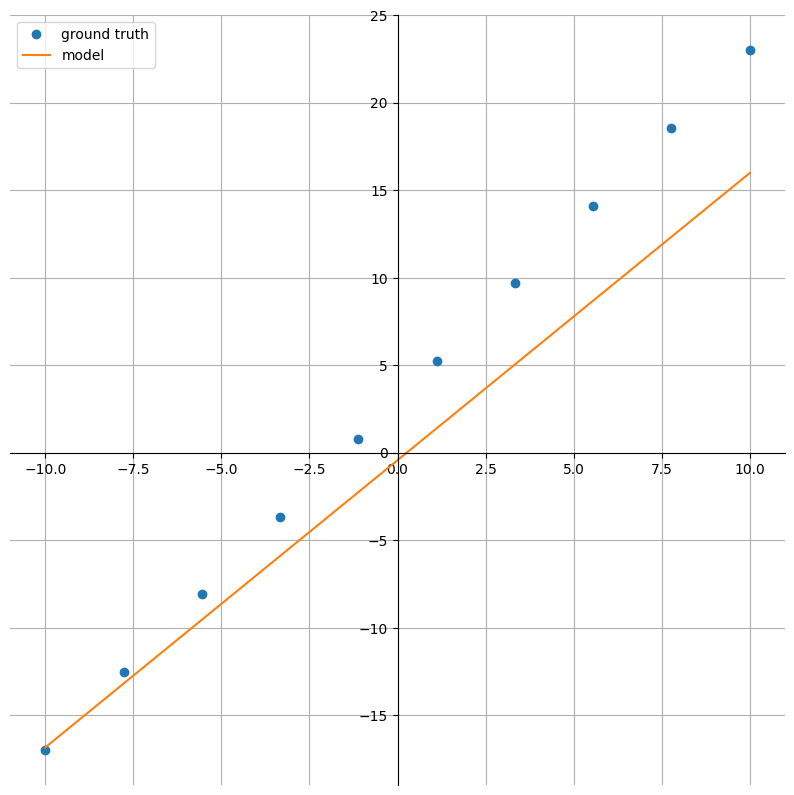

Epoach: 10; Train Loss: 3.5168237313628197


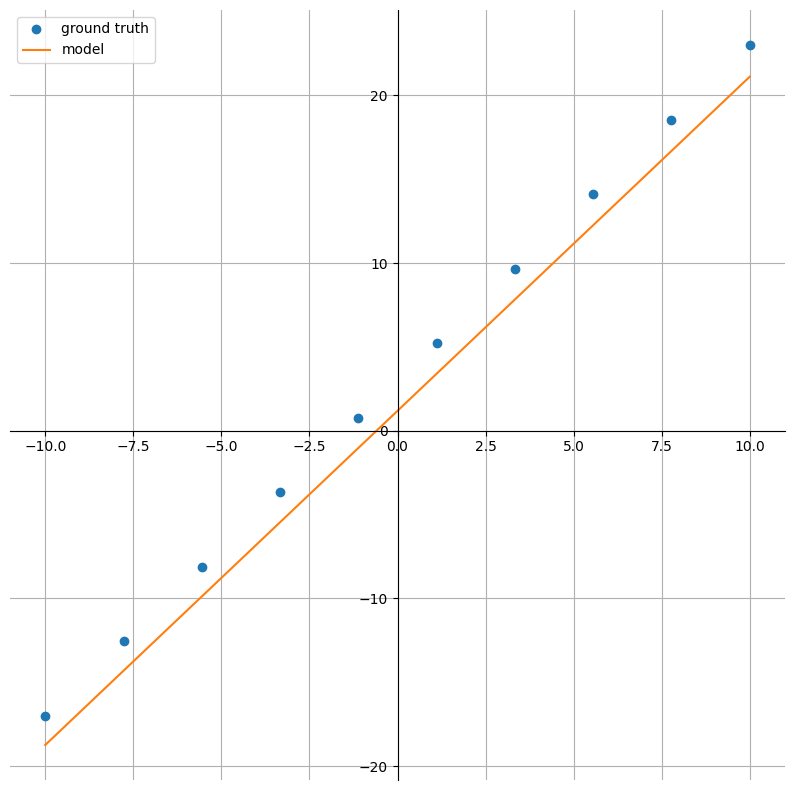

Epoach: 20; Train Loss: 0.9753503892570734


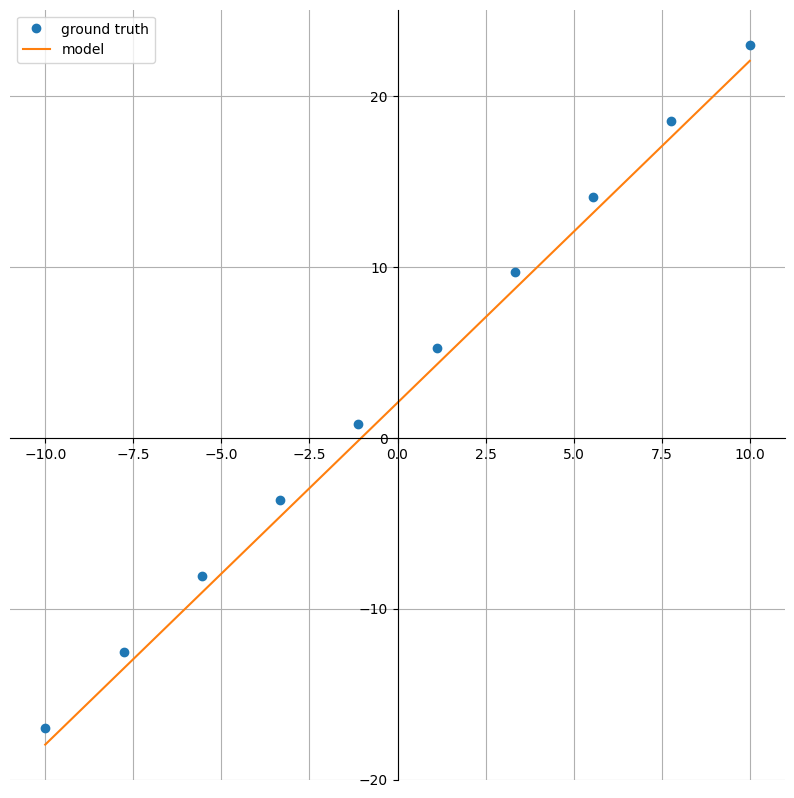

Epoach: 30; Train Loss: 0.27081211656332016


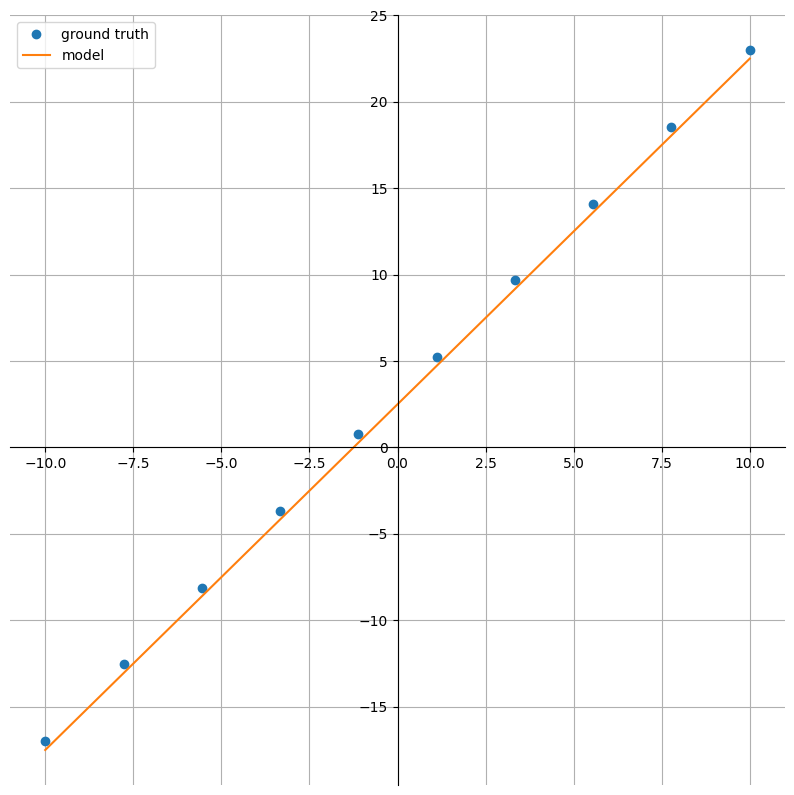

Epoach: 40; Train Loss: 0.0751080815680325


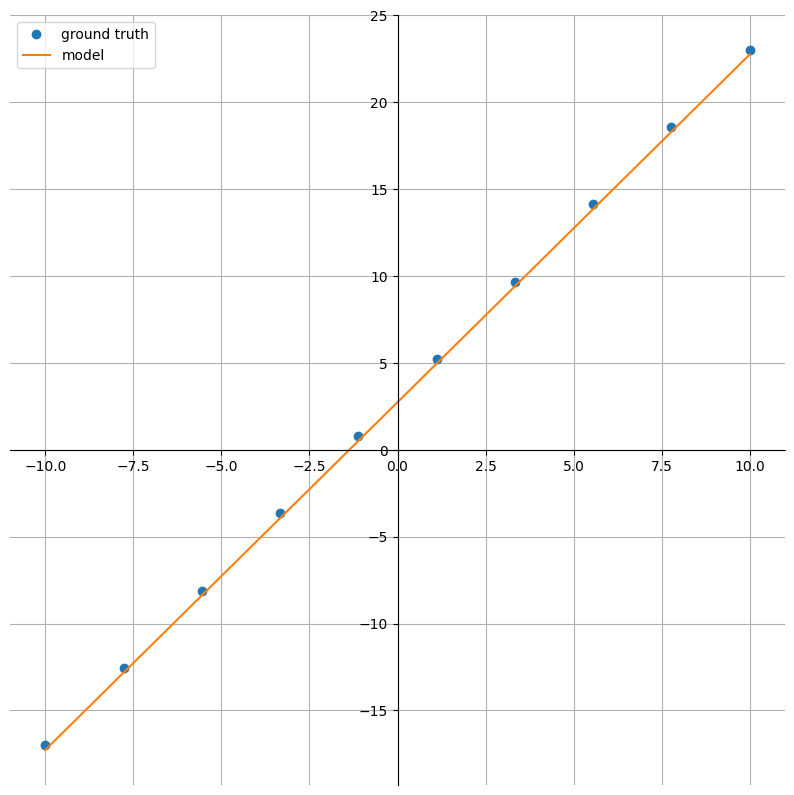

Epoach: 50; Train Loss: 0.020839461649302393


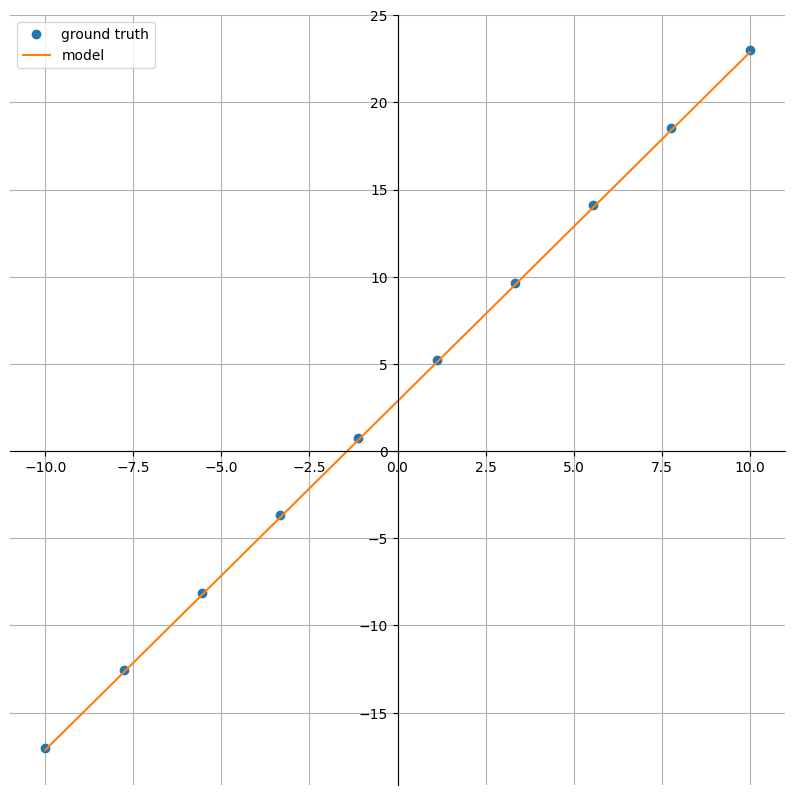

Epoach: 60; Train Loss: 0.005781962085166015


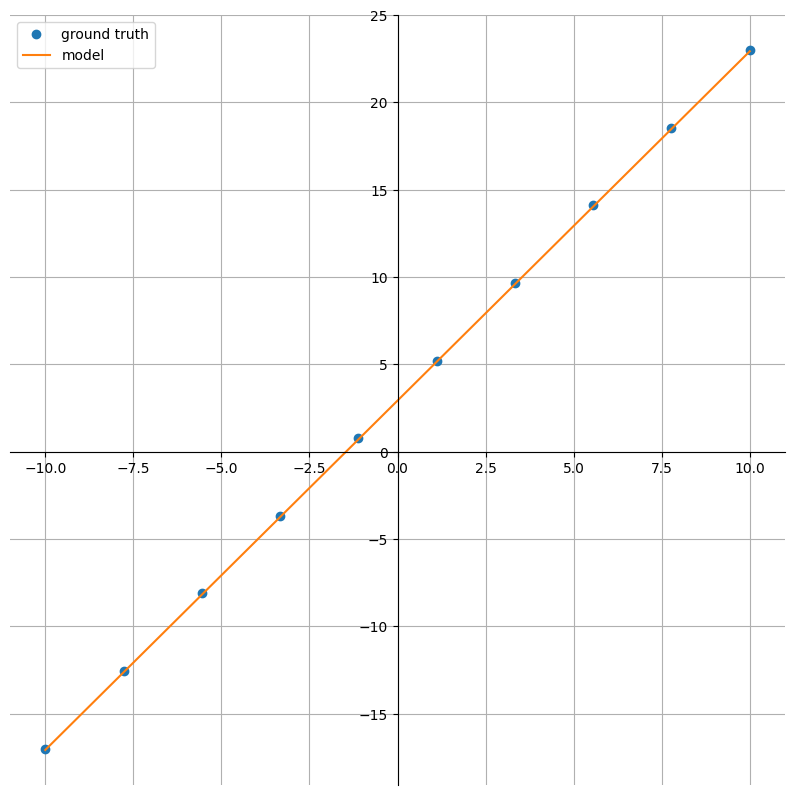

Epoach: 70; Train Loss: 0.0016051608545240015


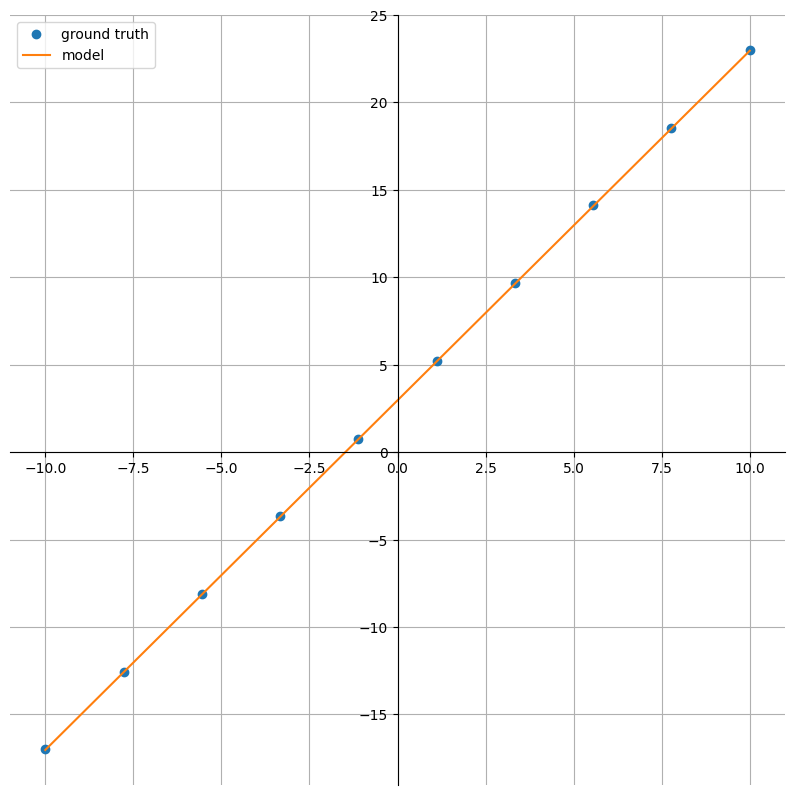

Epoach: 80; Train Loss: 0.0004449779953574762


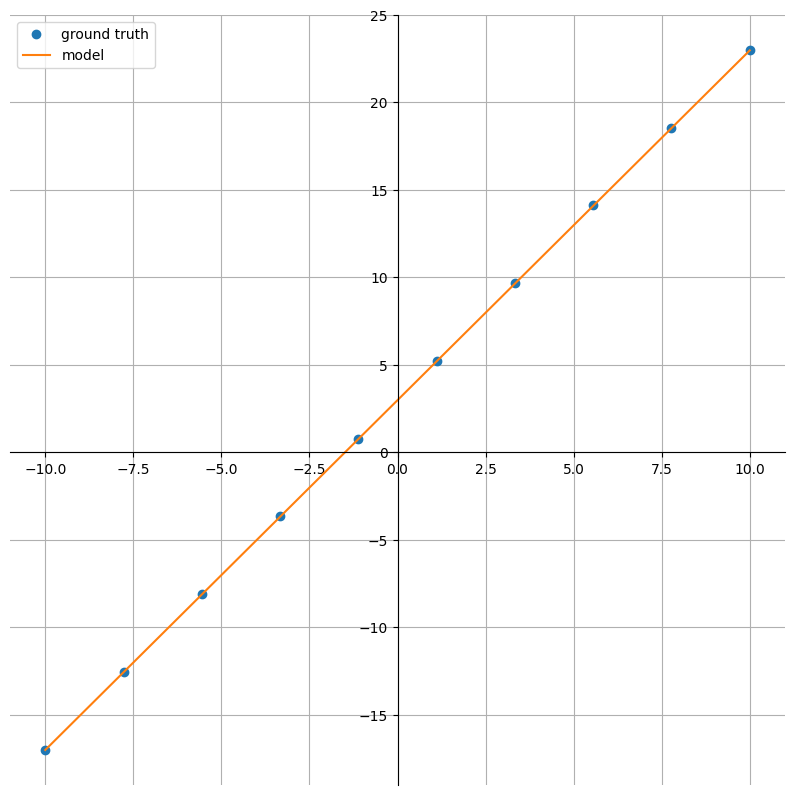

Epoach: 90; Train Loss: 0.00012342591890046606


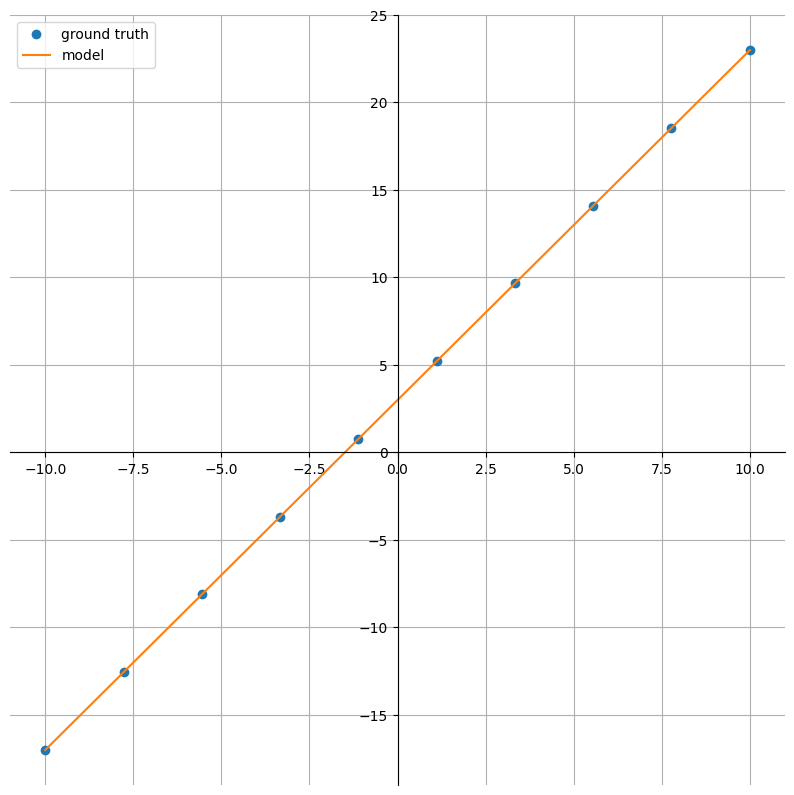

Epoach: 100; Train Loss: 3.4256609296789975e-05


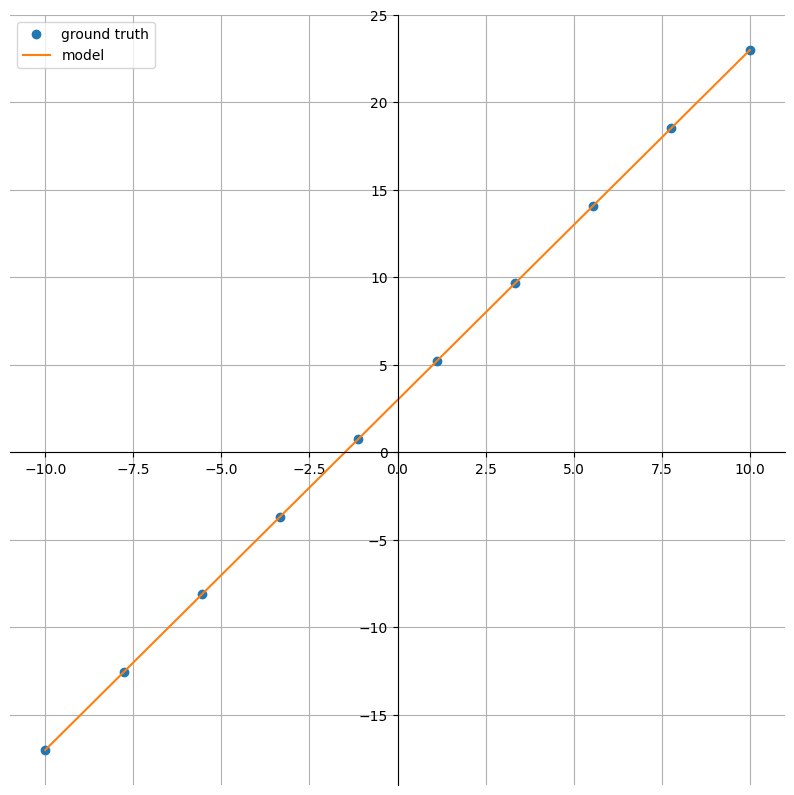

Epoach: 110; Train Loss: 9.520802393581107e-06


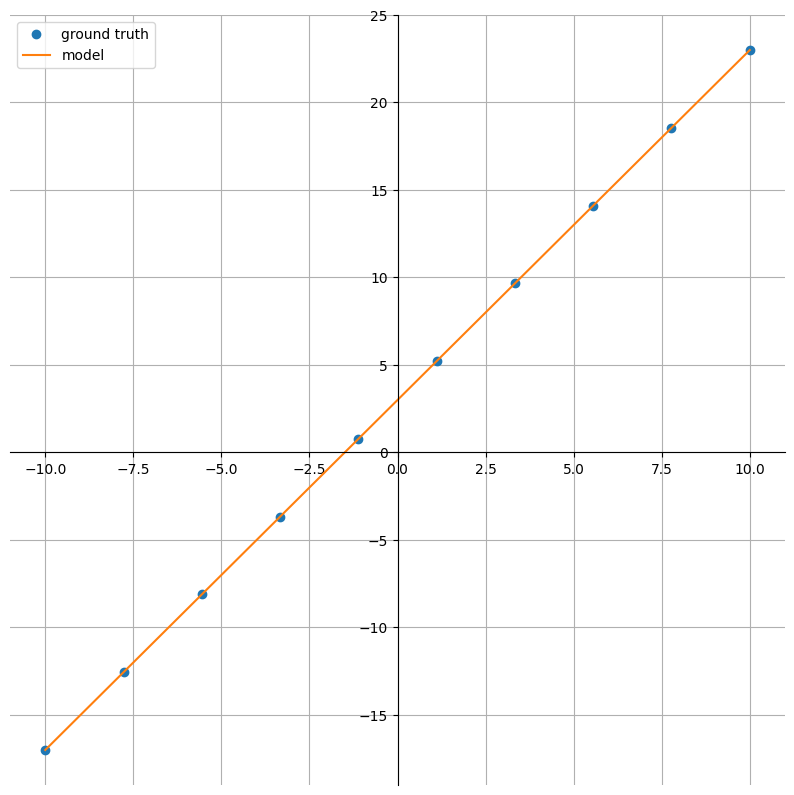

Epoach: 120; Train Loss: 2.639373555268776e-06


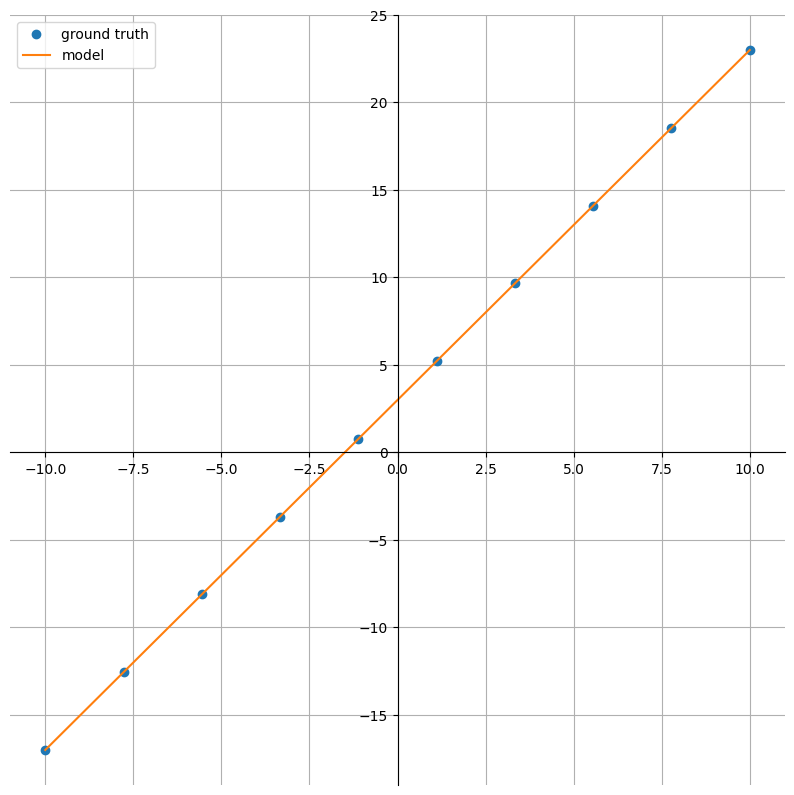

Epoach: 130; Train Loss: 7.326181794553577e-07


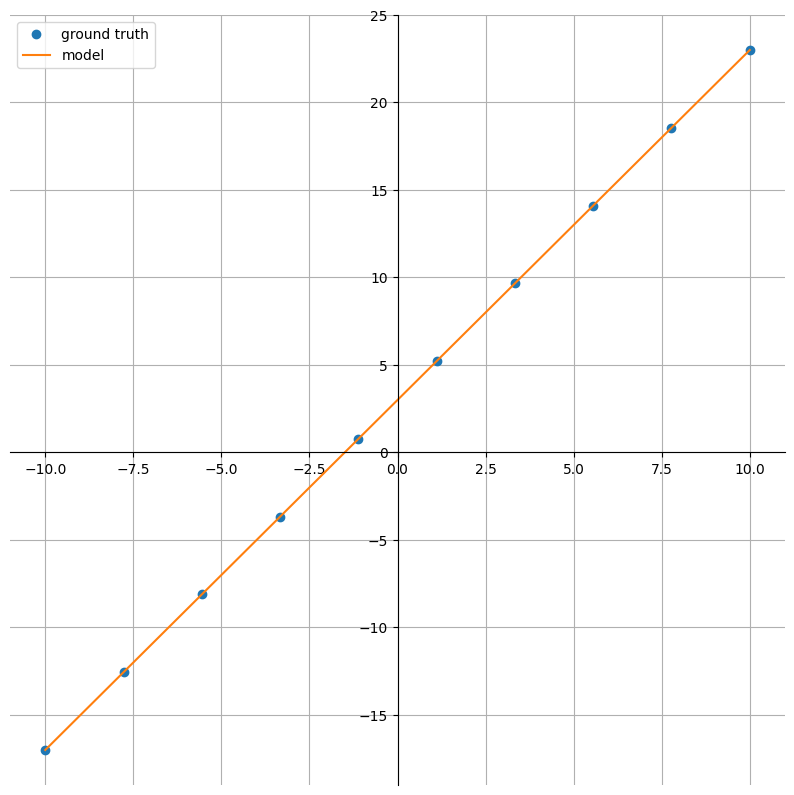

Epoach: 140; Train Loss: 2.0455805760377643e-07


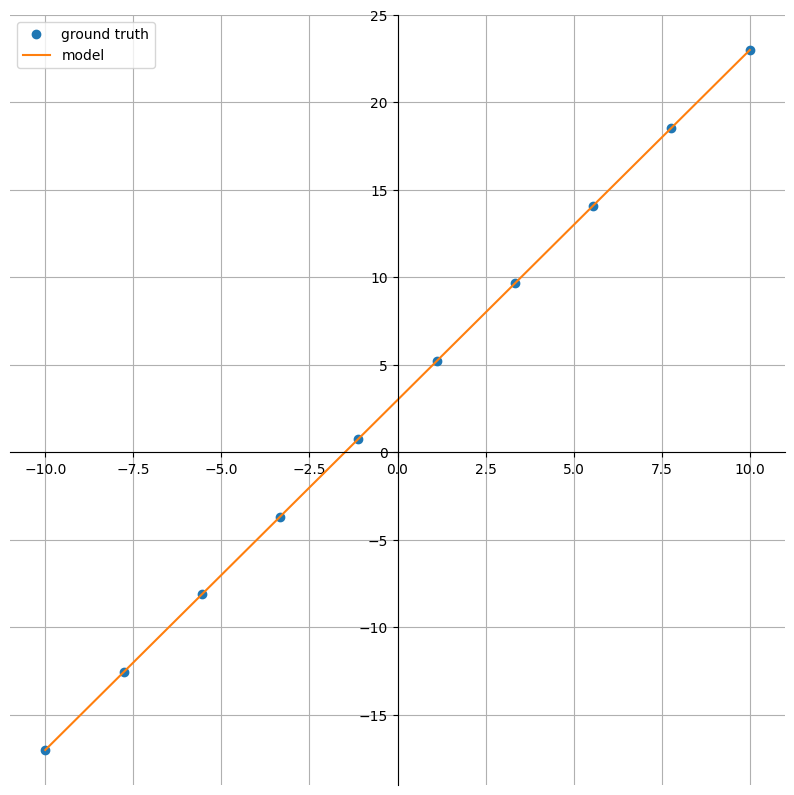

Epoach: 150; Train Loss: 5.8417836346080776e-08


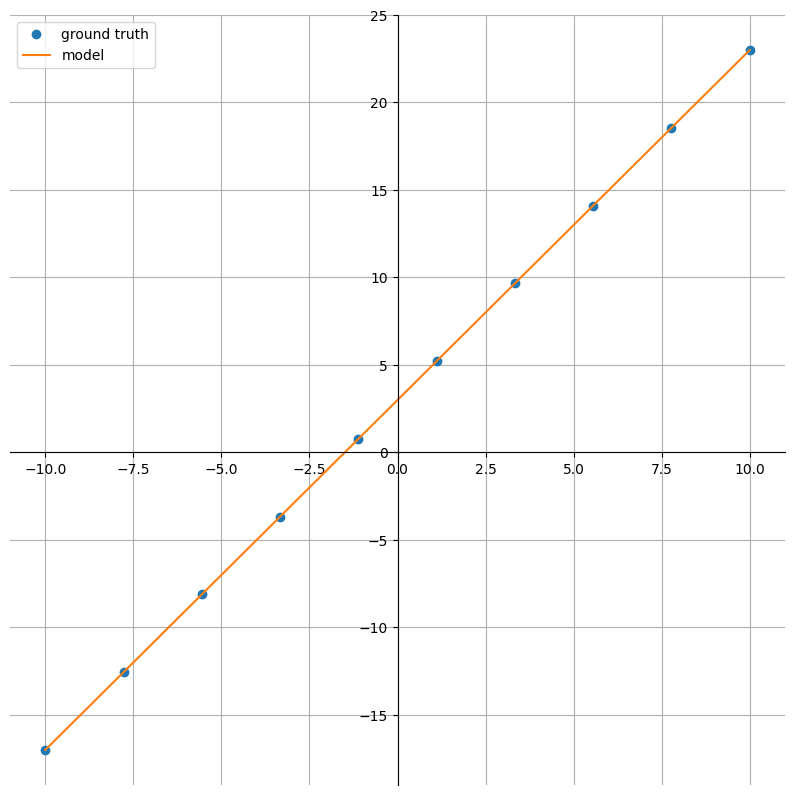

Epoach: 160; Train Loss: 1.7820881159646973e-08


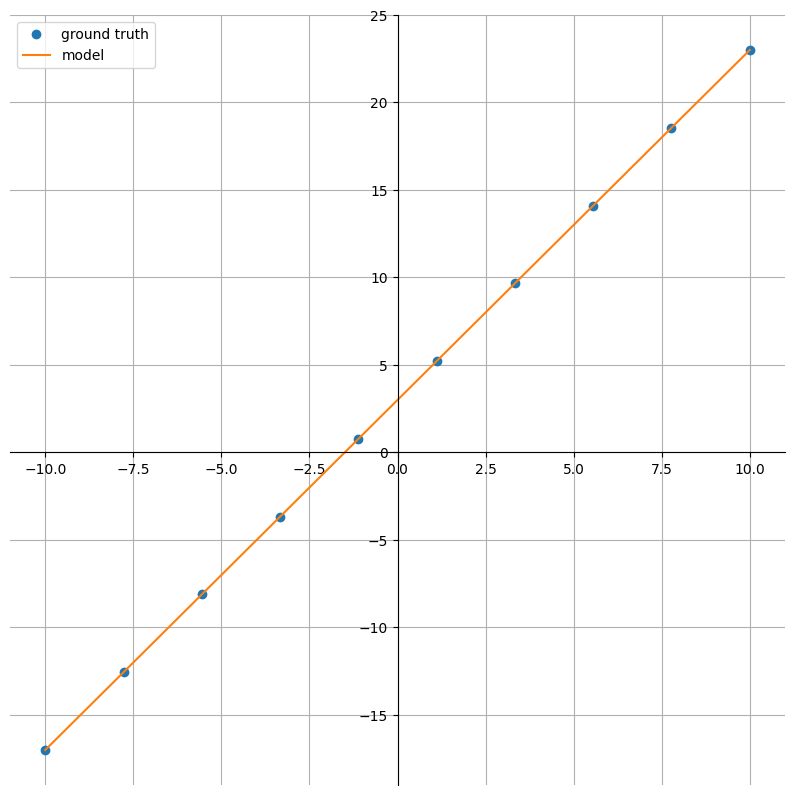

Epoach: 170; Train Loss: 3.52704223466338e-09


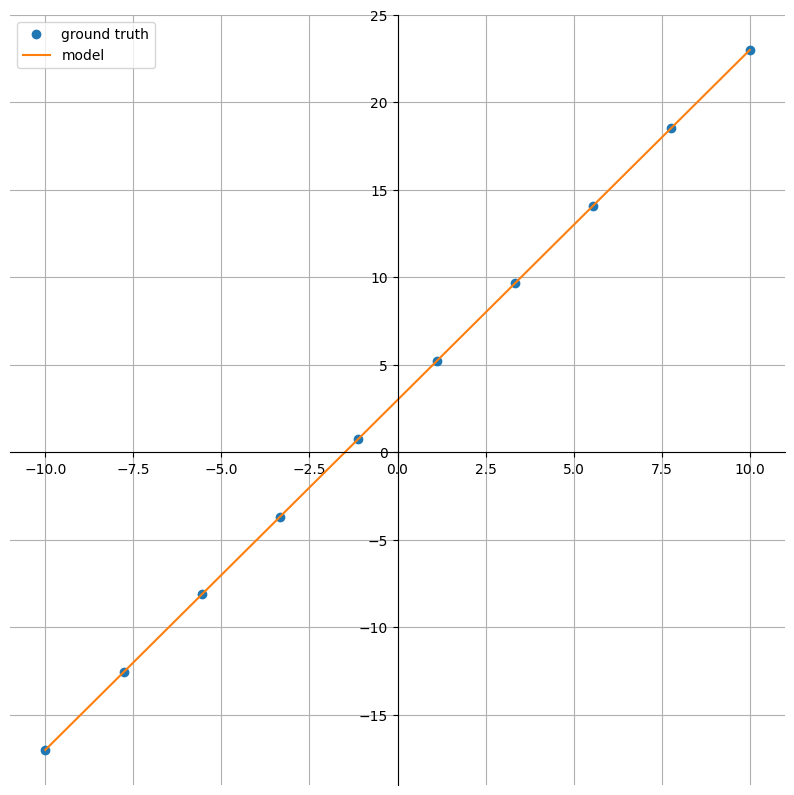

Epoach: 180; Train Loss: 3.381577566574645e-09


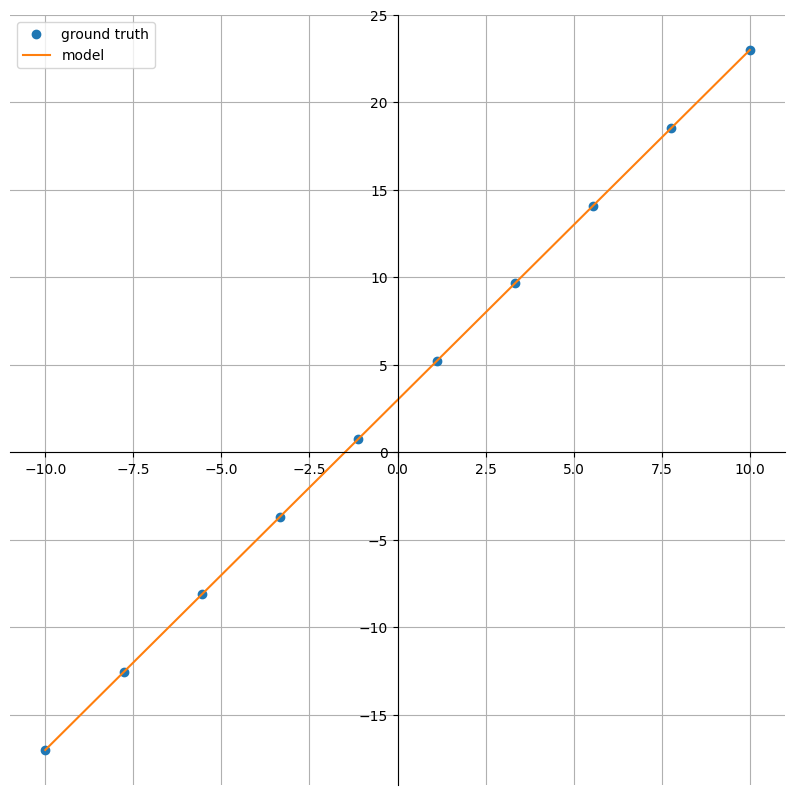

Epoach: 190; Train Loss: 3.3633272139566017e-09


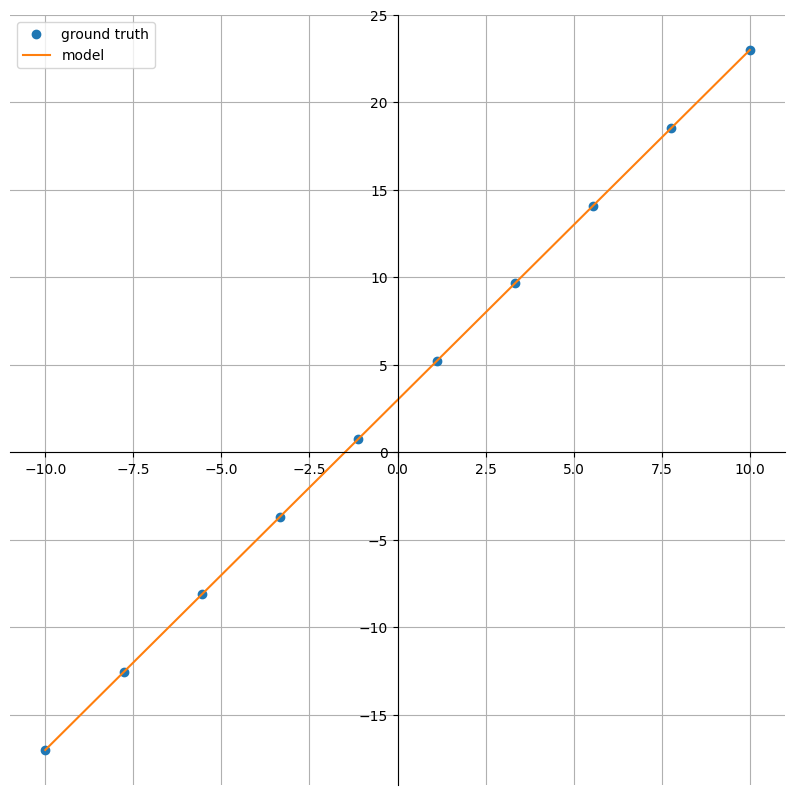

Epoach: 200; Train Loss: 3.361095249343471e-09


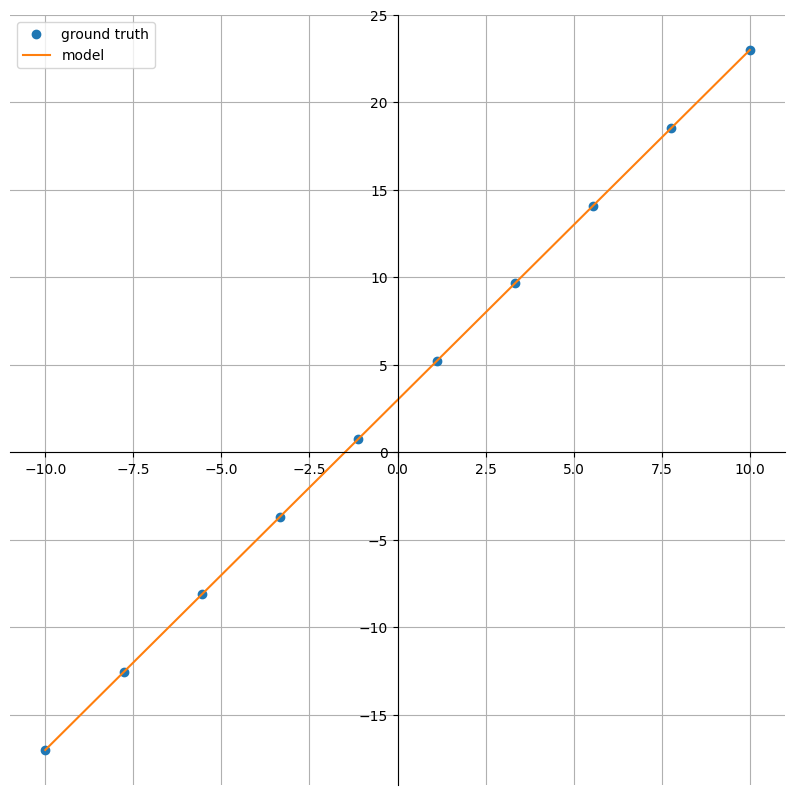

Test Loss: 3.31833160949202e-09


In [13]:
model.to(device)
epochs = 201
for t in range(epochs):
  train_loss = train(model, train_dataloader, lossfunc, optimizer)
  if t % 10 == 0:
    print(f'Epoach: {t}; Train Loss: {train_loss}')
    plot_comparinson(line, model)

test_loss = test(model, test_dataloader, lossfunc)
print(f'Test Loss: {test_loss}')

# Novo Exemplo

In [39]:
class Network (nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(1, 128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,8),
        nn.ReLU(),
        nn.Linear(8,1)
    )
  def forward(self,x):
    return self.layers(x)

In [40]:
model = Network().to(device)

In [41]:
from math import cos
f = lambda x: cos(x/2)

In [42]:
train_dataset = AlgebraicDataset(f, interval,train_nsamples)
test_dataset = AlgebraicDataset(f, interval, test_nsamples)

train_dataloader = DataLoader(train_dataset,batch_size= 64, shuffle = True)
test_dataloader = DataLoader(train_dataset,batch_size= test_nsamples, shuffle = True)

In [43]:
lossfunc = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

Epoach: 0; Train Loss: 0.5013190638273954


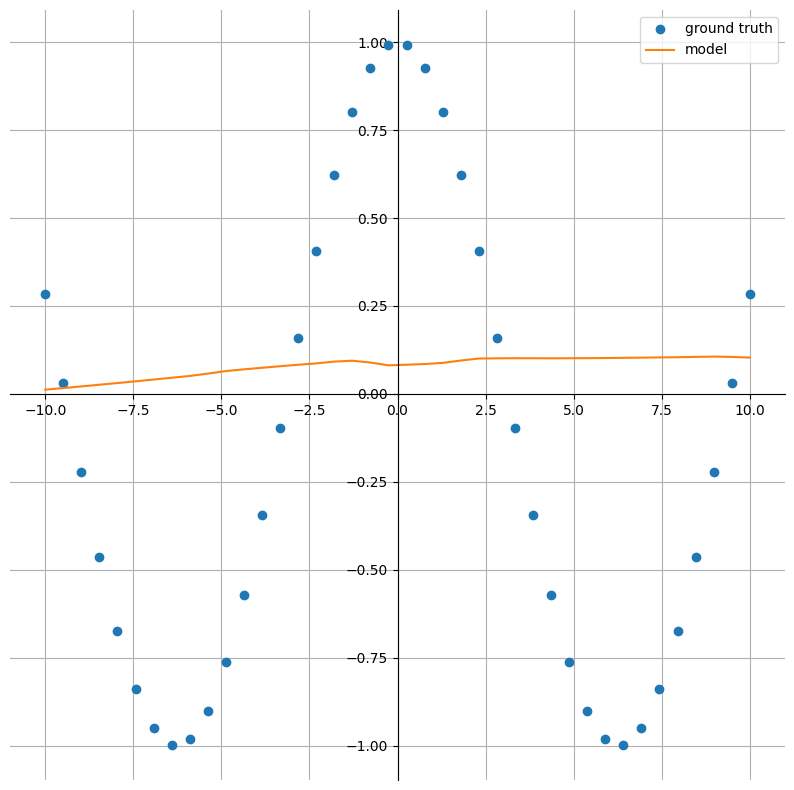

Epoach: 1000; Train Loss: 0.004315112280892208


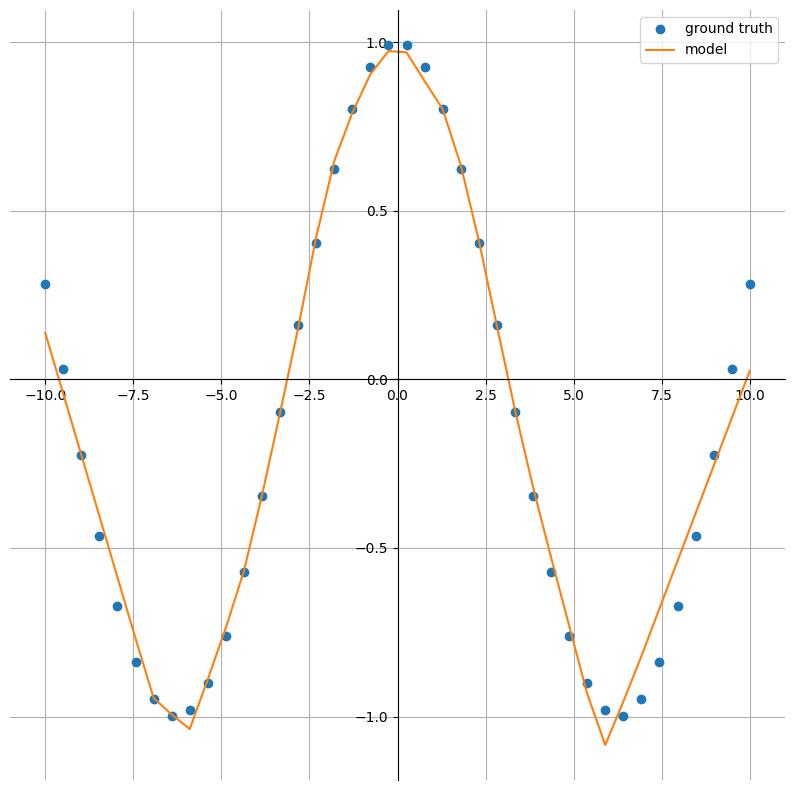

Epoach: 2000; Train Loss: 0.000645196527329972


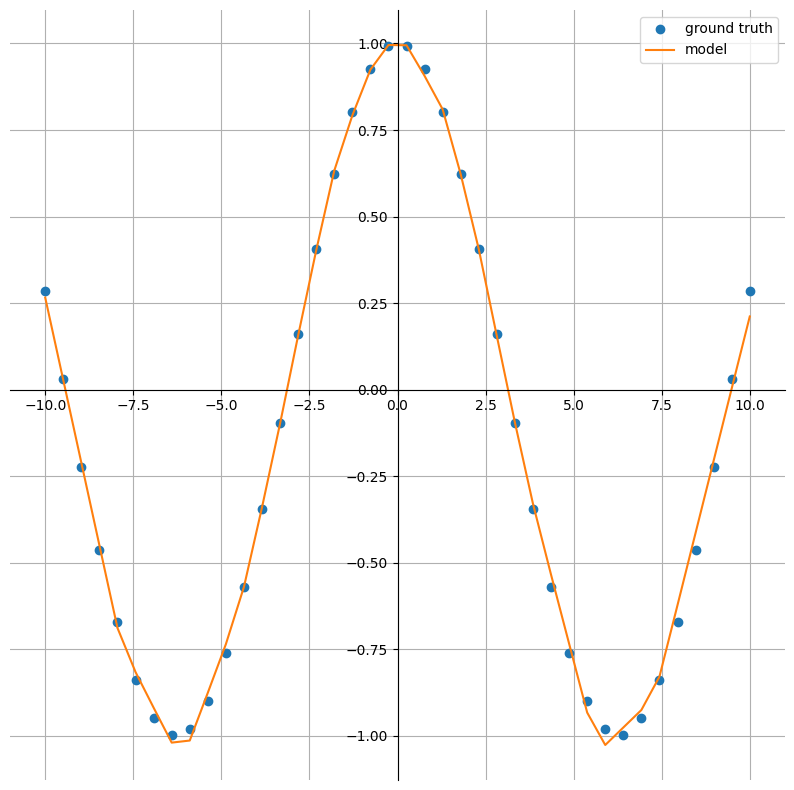

Epoach: 3000; Train Loss: 0.0005059435588918859


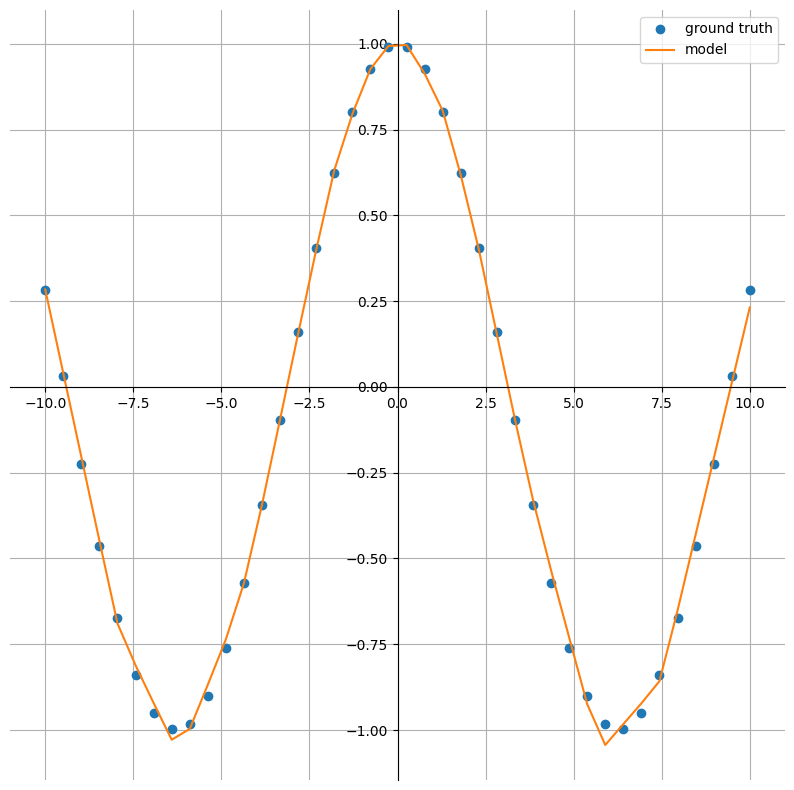

Epoach: 4000; Train Loss: 0.0004384409194244654


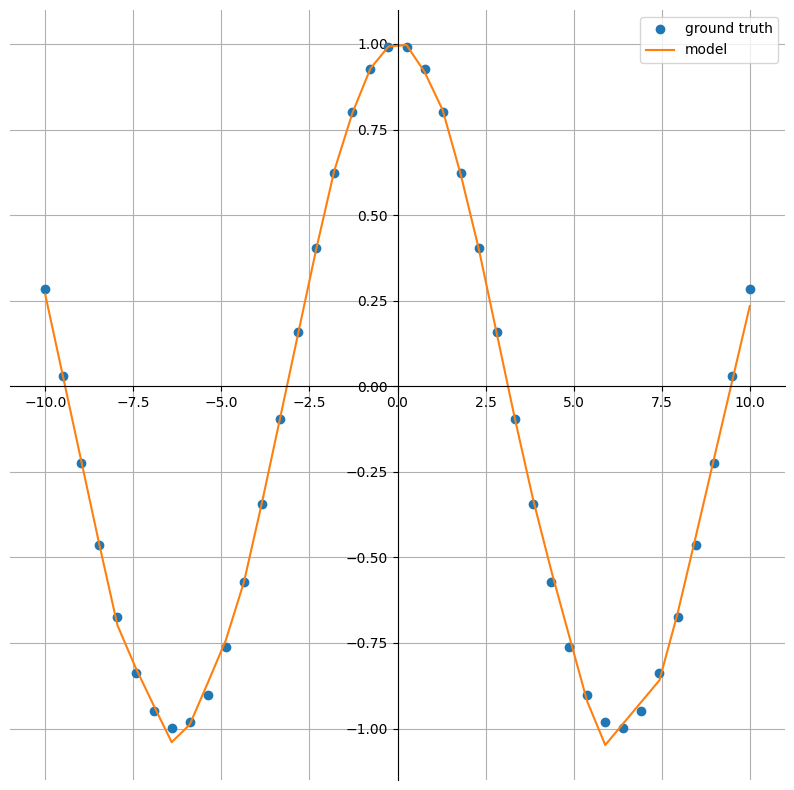

Epoach: 5000; Train Loss: 0.00040141737281373935


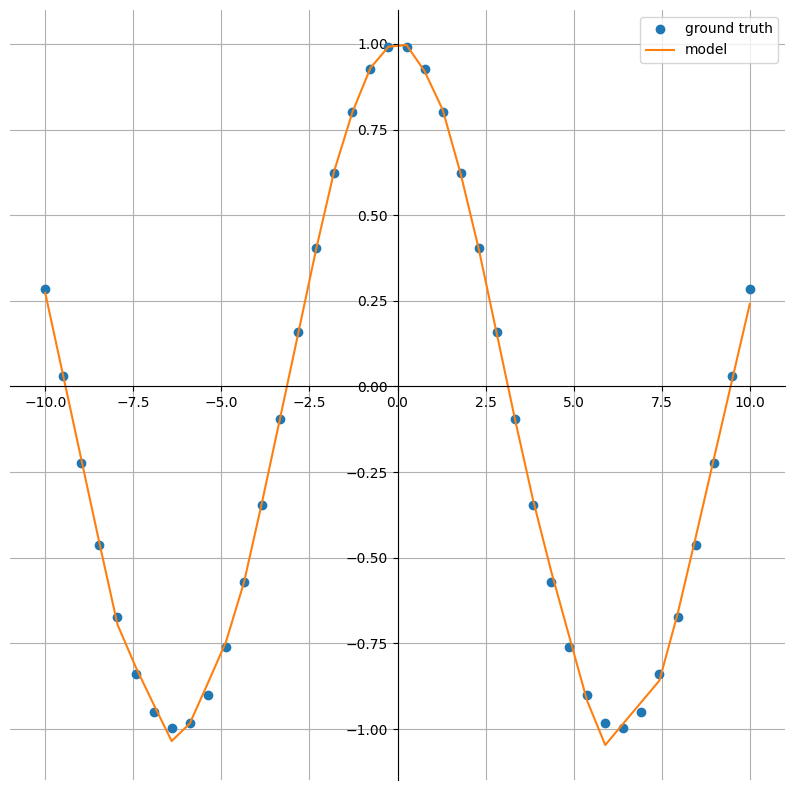

Epoach: 6000; Train Loss: 0.00036416484181245323


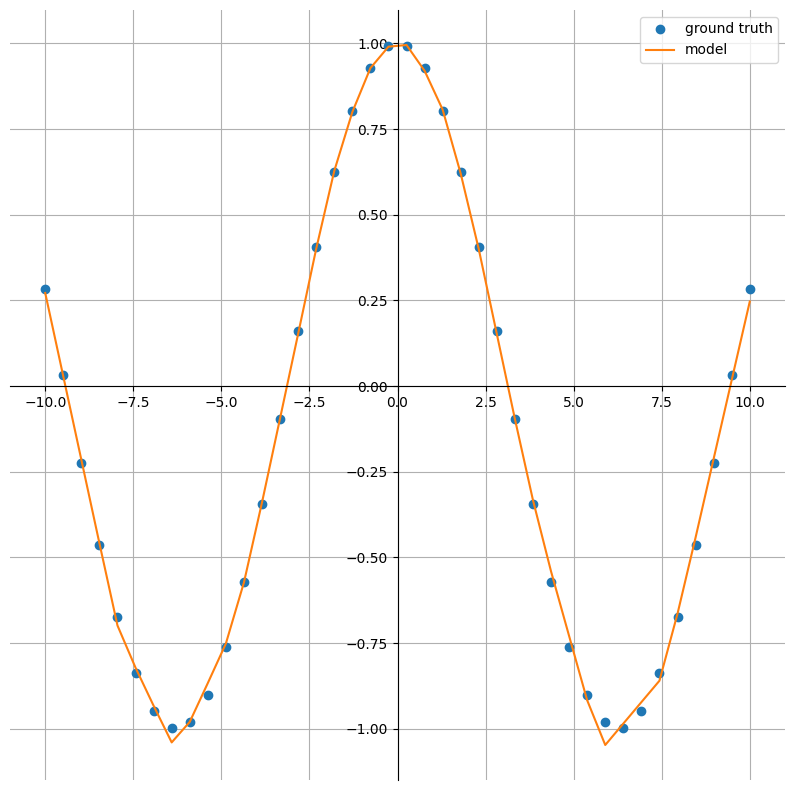

Epoach: 7000; Train Loss: 0.00033643163078522775


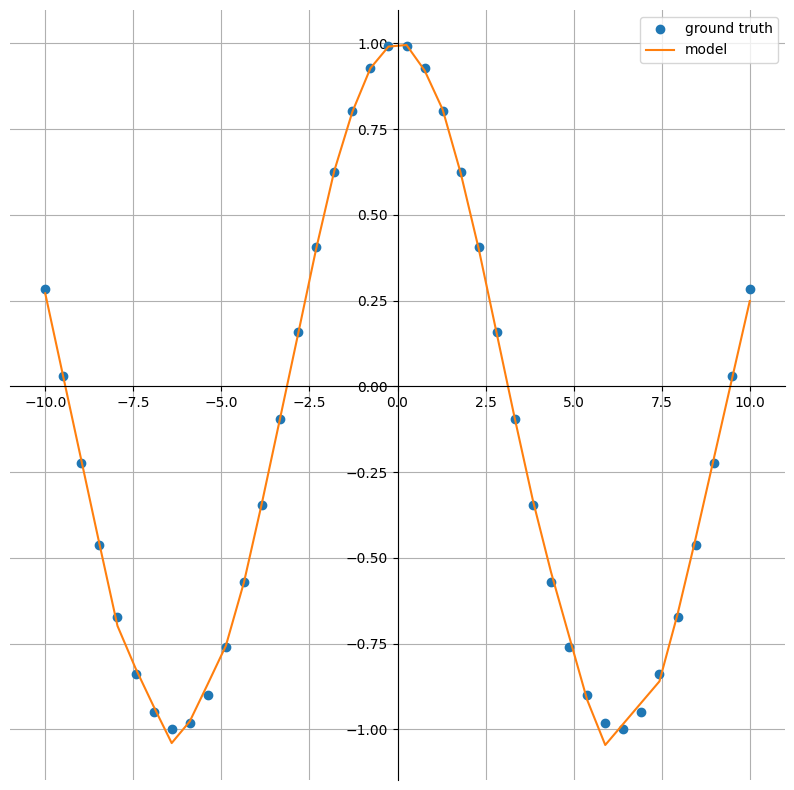

Epoach: 8000; Train Loss: 0.000314777822495671


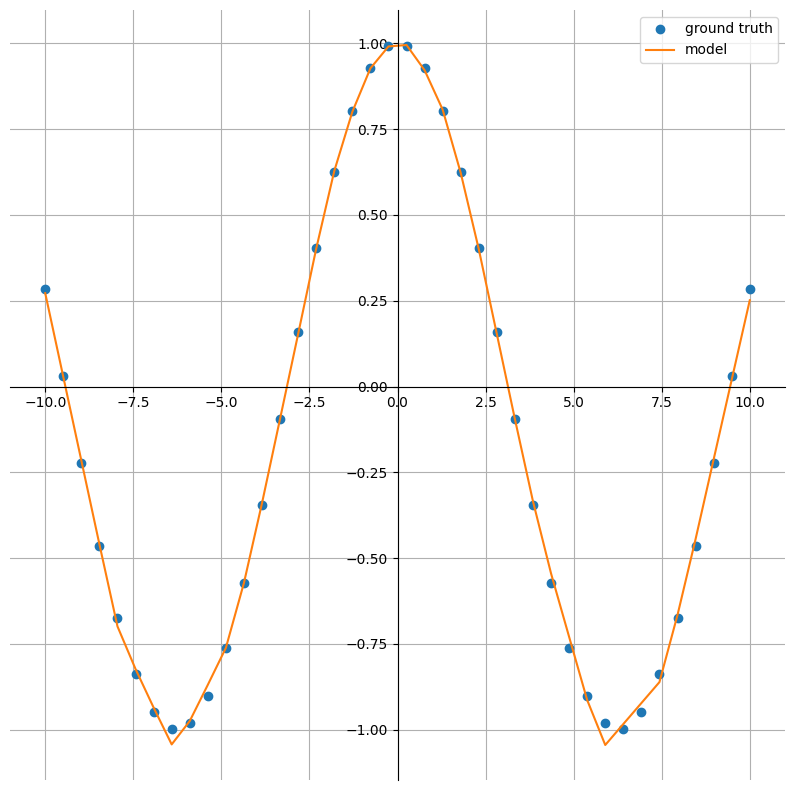

Epoach: 9000; Train Loss: 0.00029950274256407283


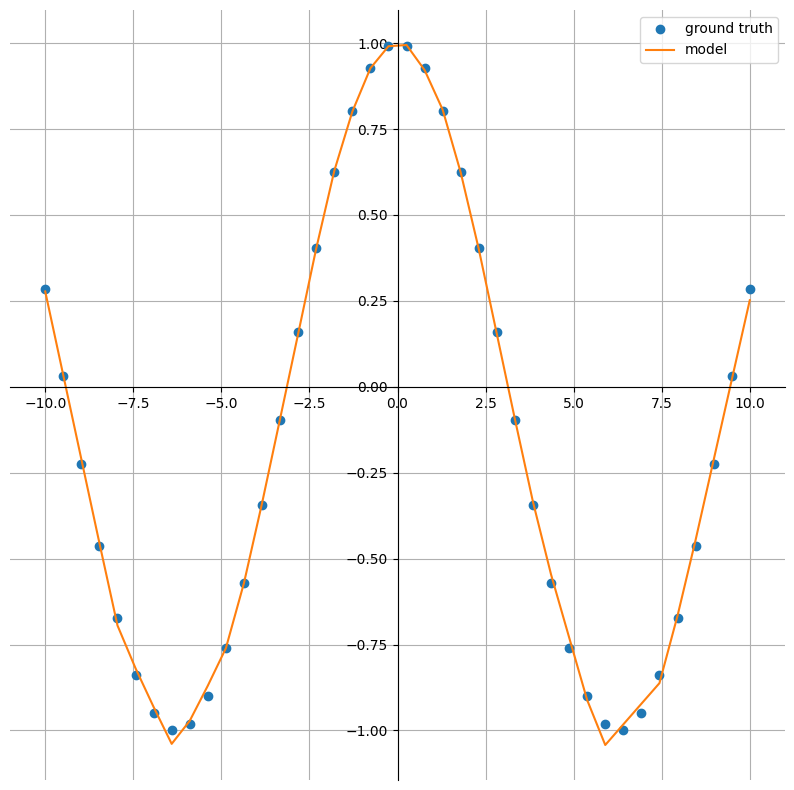

Epoach: 10000; Train Loss: 0.00027414585292717675


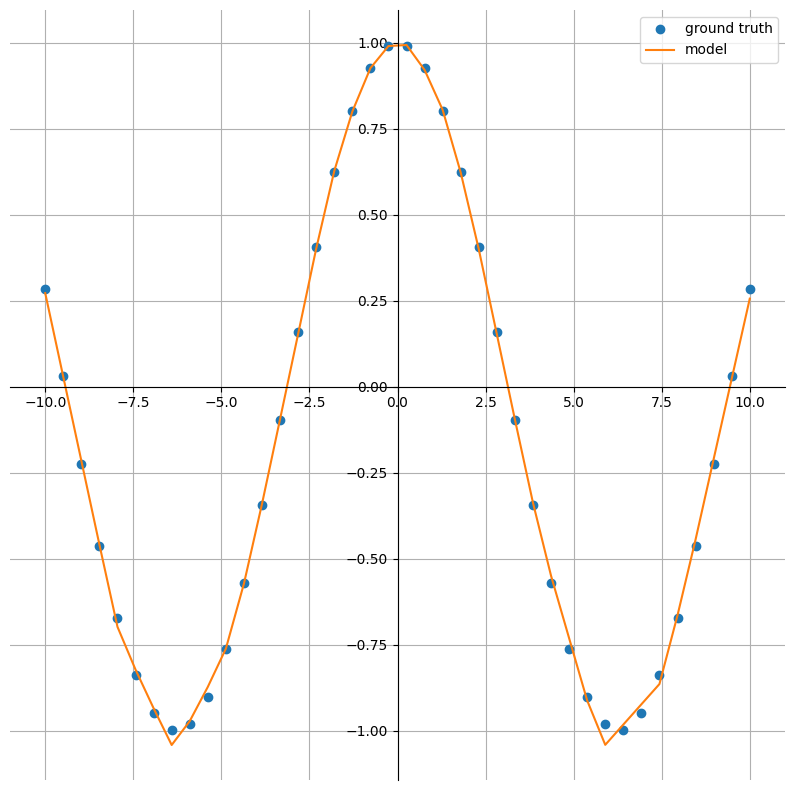

Epoach: 11000; Train Loss: 0.0002612247826618841


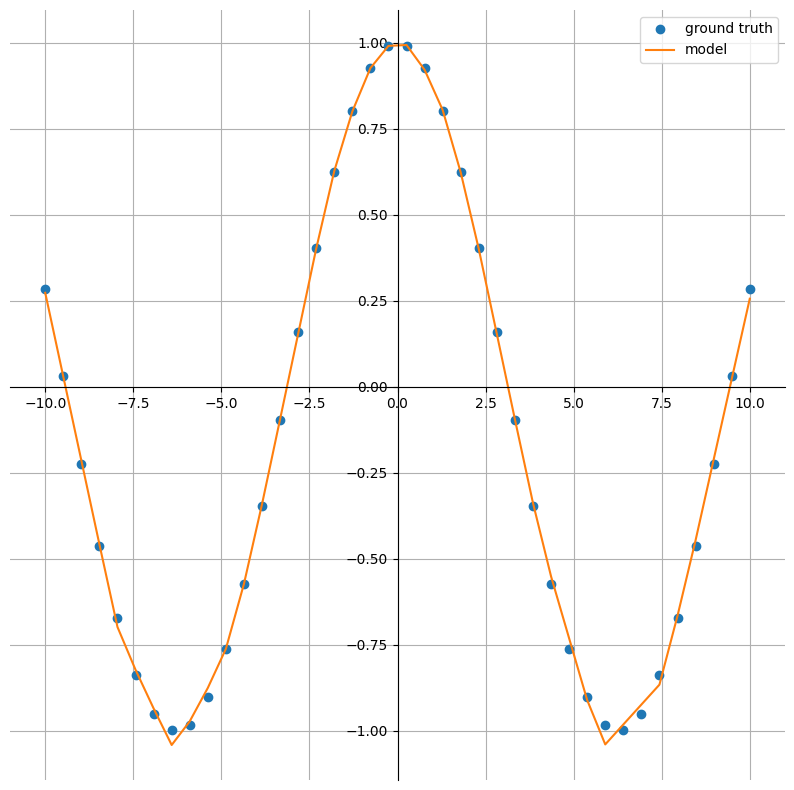

Epoach: 12000; Train Loss: 0.0002478872179381142


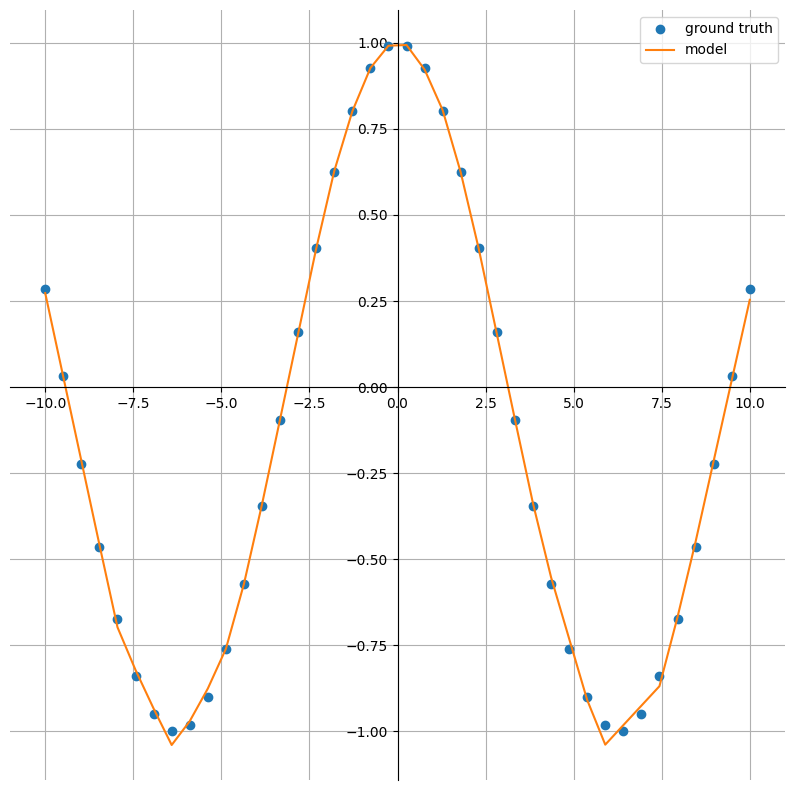

Epoach: 13000; Train Loss: 0.00023937926835060352


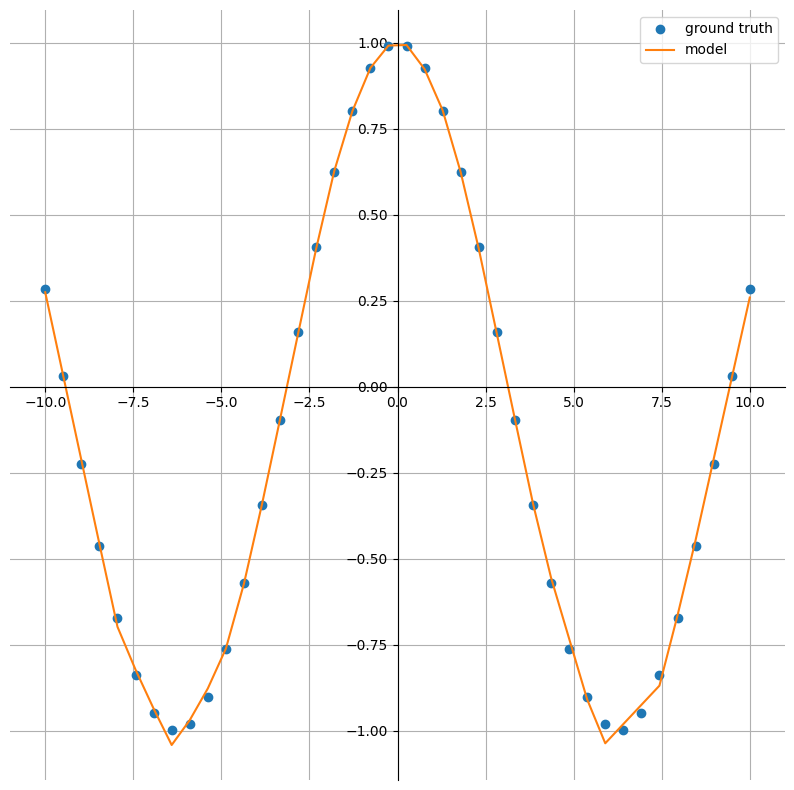

Epoach: 14000; Train Loss: 0.00022225257453101221


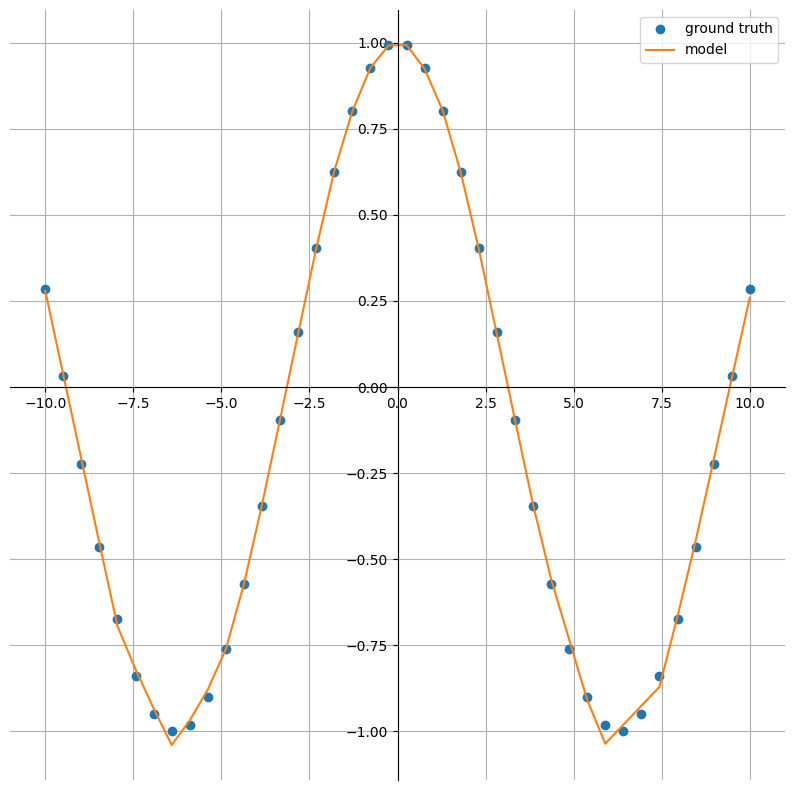

Epoach: 15000; Train Loss: 0.00021088007224534522


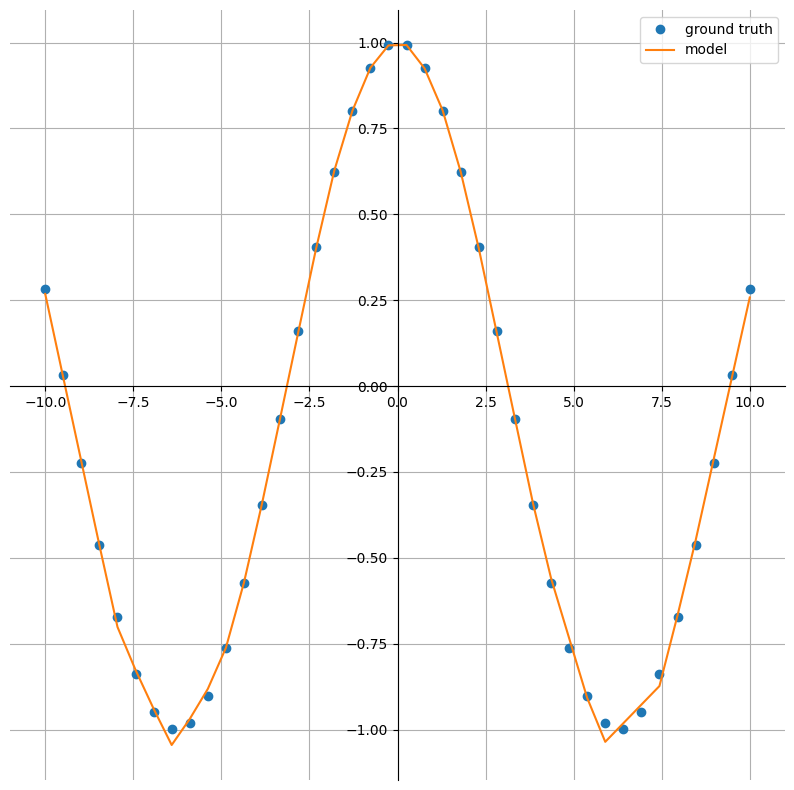

Epoach: 16000; Train Loss: 0.000207325396786473


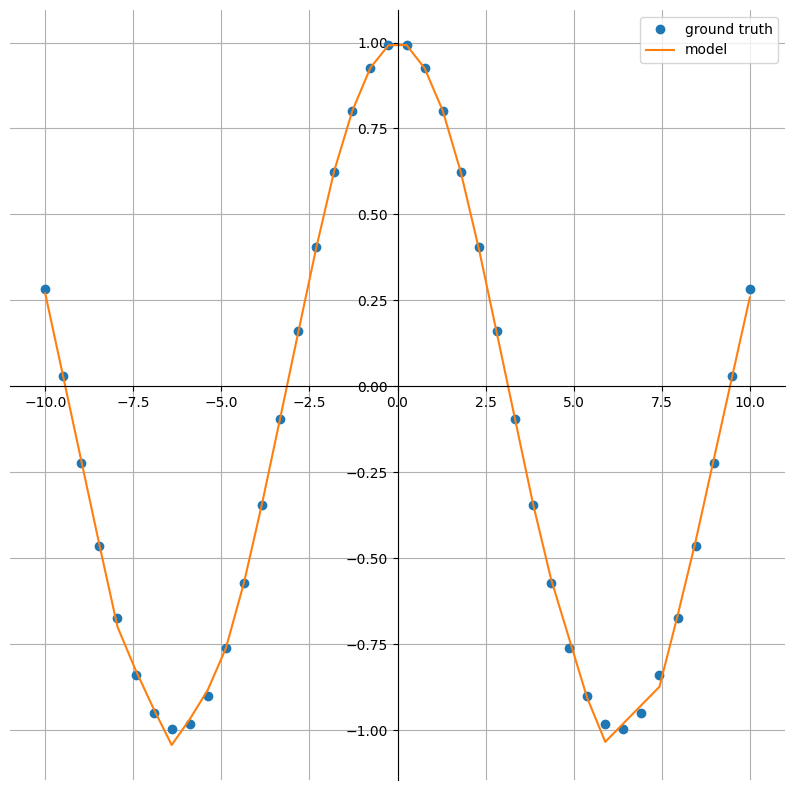

Epoach: 17000; Train Loss: 0.00019246888041379862


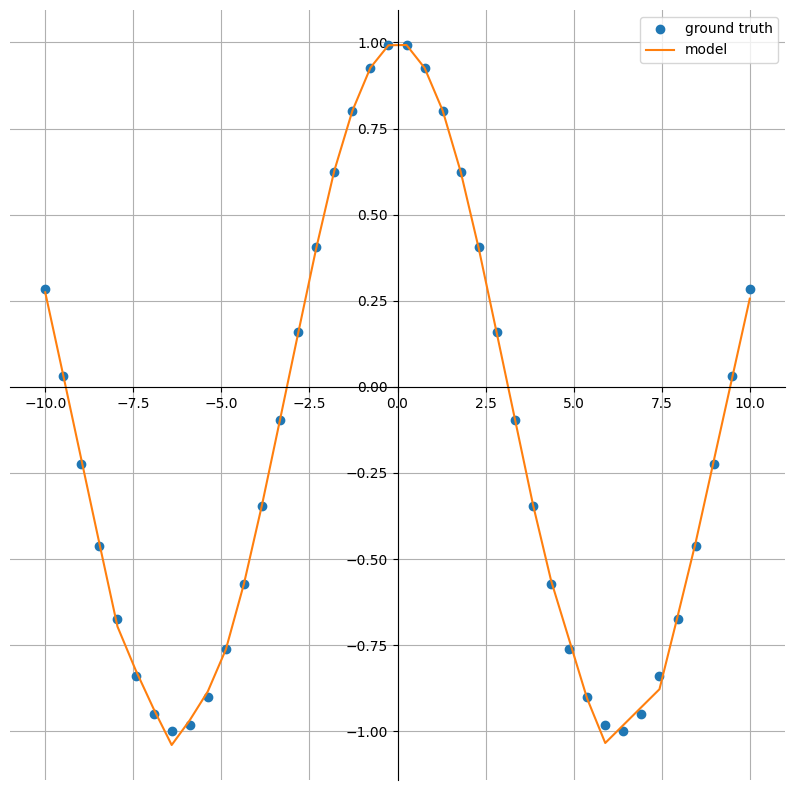

Epoach: 18000; Train Loss: 0.00018986440409207717


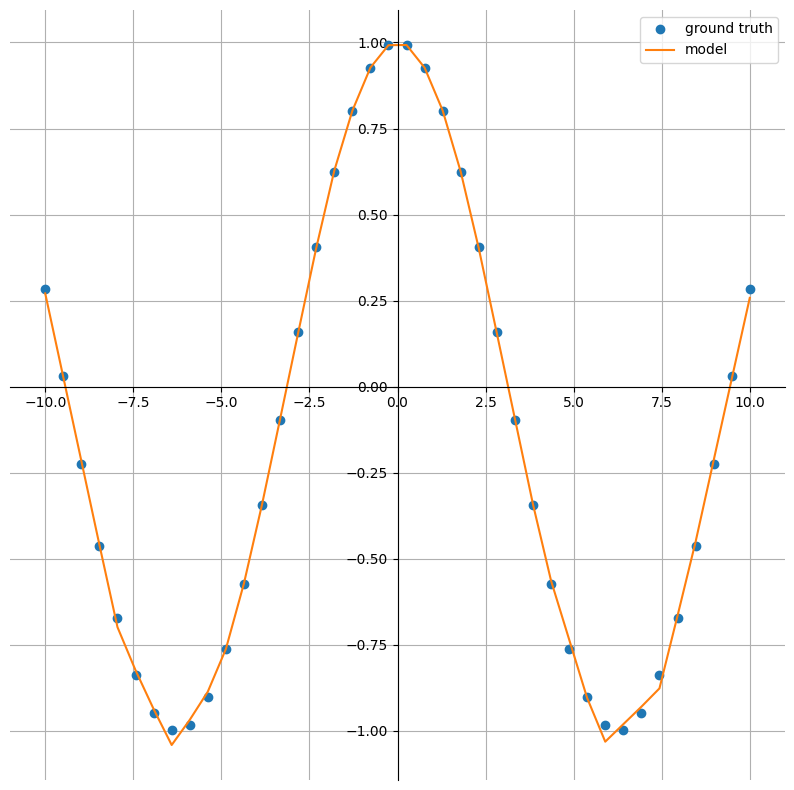

Epoach: 19000; Train Loss: 0.00018149736661143834


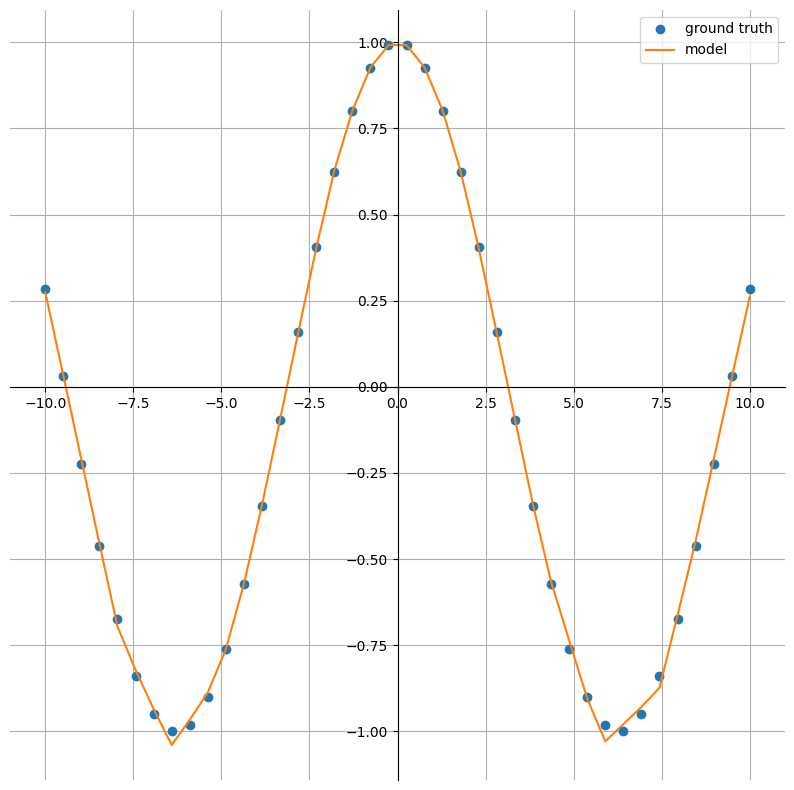

Epoach: 20000; Train Loss: 0.00017113721651185188


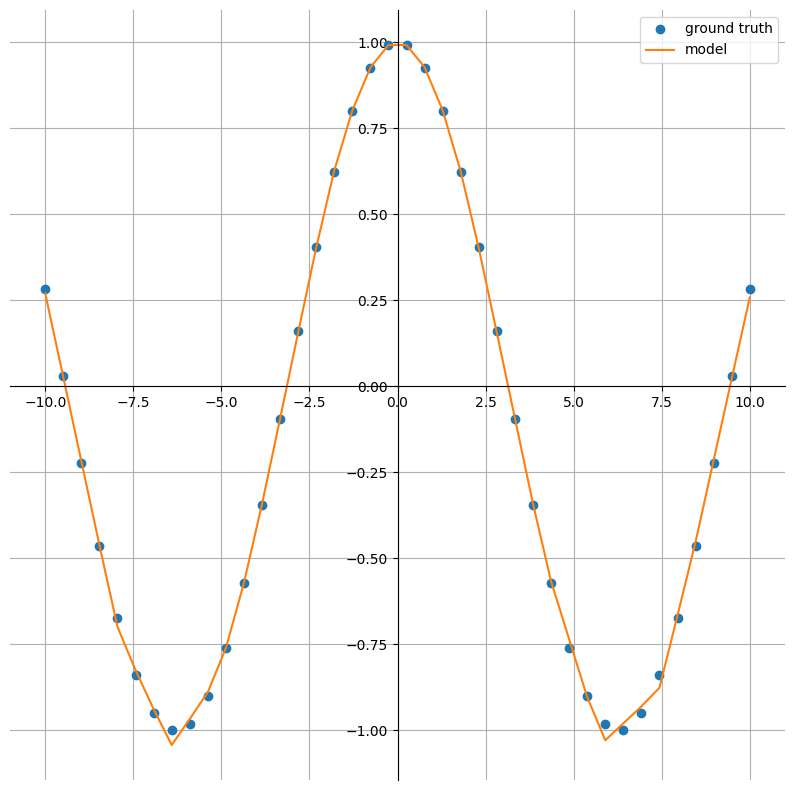

Test Loss: 0.0001729896459437441


In [44]:
epochs = 20001
for t in range(epochs):
  train_loss = train(model, train_dataloader, lossfunc, optimizer)
  if t % 1000 == 0:
    print(f'Epoach: {t}; Train Loss: {train_loss}')
    plot_comparinson(f, model, nsamples = 40)

test_loss = test(model, test_dataloader,lossfunc)
print(f'Test Loss: {test_loss}')